In [21]:
import numpy as np 
import matplotlib.pyplot as plt

In [22]:
# Module 1 Coding Task : Interatomic Interactions
from numpy.linalg import slogdet
from numpy import sign
import numpy as np
"""
Calculates reduced potential energy and force magnitude for a pair
of atoms .
TASK : Use the equations to implement the Lennard - Jones potential and
force .
REQUIREMENTS :
1. Implement the shifted potential : phi (r) - phi (rc).
2. Return the force magnitude divided by r ( force /r).
"""
def calculate_lj_properties(r_sq, r_cutoff_sq):
    inv_rc2 = 1.0 / r_cutoff_sq
    inv_rc6 = inv_rc2**3
    inv_rc12 = inv_rc6**2
    phi_cut = 4 * (inv_rc12 - inv_rc6)
    
    inv_r2 = 1.0 / r_sq
    inv_r6 = inv_r2**3
    inv_r12 = inv_r6**2
    
    phi = 4 * (inv_r12 - inv_r6)
    

    potE = phi - phi_cut
    
    force_by_r = 48 * inv_r2 * (inv_r12 - 0.5 * inv_r6)

    return potE, force_by_r



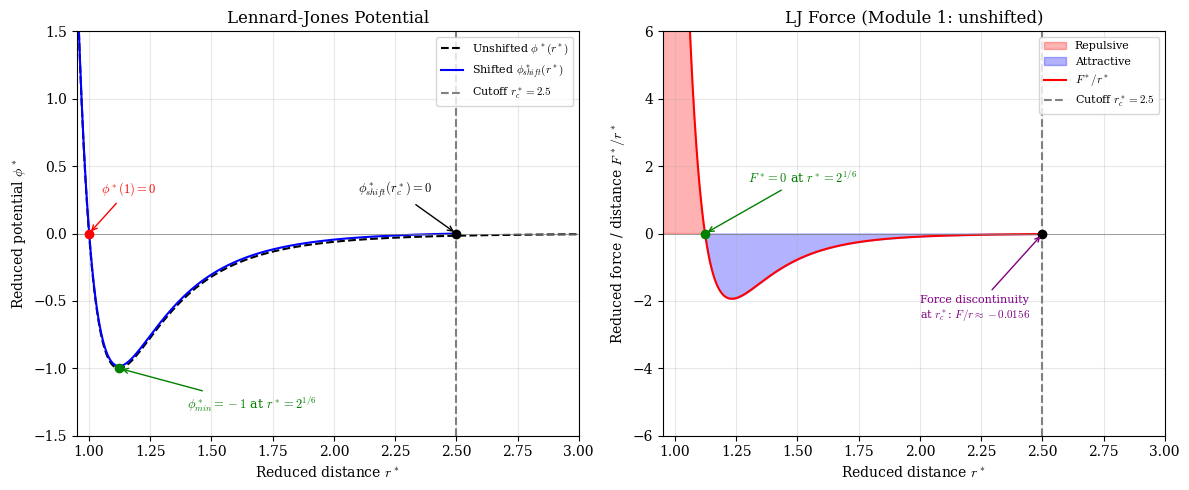

In [23]:
from matplotlib import rcParams
rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",      # Computer Modern for math
    "font.serif": ["DejaVu Serif"],
})
r_cutoff = 2.5
r_cutoff_sq = r_cutoff**2

r_vals = np.linspace(0.95, 3.0, 1000)
r_sq_vals = r_vals**2

potE_vals = []
force_vals = []

for r_sq in r_sq_vals:
    if r_sq < r_cutoff_sq:
        p, f = calculate_lj_properties(r_sq, r_cutoff_sq)
    else:
        p, f = None, None
    potE_vals.append(p)
    force_vals.append(f)

potE_vals = np.array(potE_vals, dtype=float)
force_vals = np.array(force_vals, dtype=float)

# Unshifted phi for plotting
inv_r2 = 1.0 / r_sq_vals
inv_r6 = inv_r2**3
inv_r12 = inv_r6**2
phi_unshifted = 4 * (inv_r12 - inv_r6)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left plot: Potential ---
ax = axes[0]
ax.plot(r_vals, phi_unshifted, 'k--', label=r'Unshifted $\phi^*(r^*)$')
ax.plot(r_vals, potE_vals, 'b-', label=r'Shifted $\phi^*_{shift}(r^*)$')
ax.axvline(x=r_cutoff, color='gray', linestyle='--', label=r'Cutoff $r_c^*=2.5$')
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlim(0.95, 3.0)
ax.set_xlabel(r'Reduced distance $r^*$')
ax.set_ylabel(r'Reduced potential $\phi^*$')
ax.set_title('Lennard-Jones Potential')
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)

# Annotations
ax.annotate(r'$\phi^*(1)=0$', xy=(1.0, 0), xytext=(1.05, 0.3),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
ax.plot(1.0, 0, 'ro', ms=6)

r_min = 2**(1/6)
phi_min = -1.0
ax.annotate(r'$\phi^*_{min}=-1$ at $r^*=2^{1/6}$', xy=(r_min, phi_min),
            xytext=(1.4, -1.3),
            arrowprops=dict(arrowstyle='->', color='green'), color='green', fontsize=9)
ax.plot(r_min, phi_min, 'go', ms=6)

phi_at_rc, _ = calculate_lj_properties(r_cutoff_sq, r_cutoff_sq)
ax.annotate(r'$\phi^*_{shift}(r_c^*)=0$', xy=(r_cutoff, 0), xytext=(2.1, 0.3),
            arrowprops=dict(arrowstyle='->', color='black'), color='black', fontsize=9)
ax.plot(r_cutoff, 0, 'ko', ms=6)

# --- Right plot: Force/r ---
ax2 = axes[1]

# Repulsive region (F/r > 0): shade red
r_rep = r_vals[force_vals > 0]
f_rep = force_vals[force_vals > 0]
ax2.fill_between(r_rep, 0, f_rep, alpha=0.3, color='red', label='Repulsive')

# Attractive region (F/r < 0): shade blue
r_att = r_vals[force_vals < 0]
f_att = force_vals[force_vals < 0]
ax2.fill_between(r_att, 0, f_att, alpha=0.3, color='blue', label='Attractive')

ax2.plot(r_vals, force_vals, 'r-', label=r'$F^*/r^*$')
ax2.axvline(x=r_cutoff, color='gray', linestyle='--', label=r'Cutoff $r_c^*=2.5$')
ax2.axhline(y=0, color='gray', linewidth=0.5)
ax2.set_ylim(-6, 6)
ax2.set_xlim(0.95, 3.0)
ax2.set_xlabel(r'Reduced distance $r^*$')
ax2.set_ylabel(r'Reduced force / distance $F^*/r^*$')
ax2.set_title('LJ Force (Module 1: unshifted)')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=8, loc="upper right")

# Annotations
f_at_rmin, _ = calculate_lj_properties(r_min**2, r_cutoff_sq)
ax2.annotate(r'$F^*=0$ at $r^*=2^{1/6}$', xy=(r_min, 0), xytext=(1.3, 1.5),
             arrowprops=dict(arrowstyle='->', color='green'), color='green', fontsize=9)
ax2.plot(r_min, 0, 'go', ms=6)

f_at_rc, _ = calculate_lj_properties(r_cutoff_sq, r_cutoff_sq)
ax2.annotate(f'Force discontinuity\nat $r_c^*$: $F/r \\approx -0.0156$',
             xy=(r_cutoff, -0.0156), xytext=(2.0, -2.5),
             arrowprops=dict(arrowstyle='->', color='purple'), color='purple', fontsize=8)
ax2.plot(r_cutoff, -0.0156, 'ko', ms=6)

plt.tight_layout()
plt.savefig('m1_lj_curves.pdf', dpi=150)
plt.show()

In [24]:
r_cutoff = 2.5
r_cutoff_sq = r_cutoff**2

print(f"Module 1 Verification Tests (r_c* = {r_cutoff})")
print("=" * 65)

# Test 1: r* = 1.0
r1 = 1.0
r1_sq = r1**2
inv_r2 = 1.0 / r1_sq
inv_r6 = inv_r2**3
phi_unshifted_1 = 4 * (inv_r6**2 - inv_r6)
potE_1, force_1 = calculate_lj_properties(r1_sq, r_cutoff_sq)
print(f"\nTest 1 — Zero-point (r* = {r1})")
print(f"  Unshifted phi*(1)      : {phi_unshifted_1:.6f}  (expected: 0.000000)")
print(f"  Force/r sign           : {'+' if force_1 > 0 else '-'}{abs(force_1):.1f}  (expected: > 0, repulsive)")

# Test 2: r* = 2^(1/6)
r2 = 2**(1/6)
r2_sq = r2**2
inv_r2 = 1.0 / r2_sq
inv_r6 = inv_r2**3
phi_unshifted_2 = 4 * (inv_r6**2 - inv_r6)
potE_2, force_2 = calculate_lj_properties(r2_sq, r_cutoff_sq)
print(f"\nTest 2 — Minimum energy (r* = 2^(1/6) ≈ {r2:.4f})")
print(f"  Unshifted phi*_min     : {phi_unshifted_2:.6f}  (expected: -1.000000)")
print(f"  Force/r at minimum     : {force_2:.2e}  (expected: ≈ 0)")

# Test 3: r* = r_c* = 2.5
r3 = 2.5
r3_sq = r3**2
potE_3, force_3 = calculate_lj_properties(r3_sq, r_cutoff_sq)
print(f"\nTest 3 — Cutoff shift (r* = r_c* = {r3})")
print(f"  Shifted phi*(r_c*)     : {potE_3:.6f}  (expected: 0.000000)")
print(f"  Force/r at r_c*        : {force_3:.4f}  (expected: non-zero)")
print()

Module 1 Verification Tests (r_c* = 2.5)

Test 1 — Zero-point (r* = 1.0)
  Unshifted phi*(1)      : 0.000000  (expected: 0.000000)
  Force/r sign           : +24.0  (expected: > 0, repulsive)

Test 2 — Minimum energy (r* = 2^(1/6) ≈ 1.1225)
  Unshifted phi*_min     : -1.000000  (expected: -1.000000)
  Force/r at minimum     : -2.11e-15  (expected: ≈ 0)

Test 3 — Cutoff shift (r* = r_c* = 2.5)
  Shifted phi*(r_c*)     : 0.000000  (expected: 0.000000)
  Force/r at r_c*        : -0.0156  (expected: non-zero)

